## Exploratory Data Analysis: The Arsenal Story

## Step 1 — Imports & Setup

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
%matplotlib inline

#Plot Style
sns.set_theme(style = 'whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Colour Pallettes
ARSENAL_RED   = '#EF0107'
ARSENAL_NAVY  = '#063672'
ARSENAL_GOLD  = '#9C824A'
LIGHT_GREY    = '#D3D3D3'

STAKES_PALETTE = {'High Stakes' : ARSENAL_RED, 'Normal':ARSENAL_GOLD}

print('✅ All imports and style settings loaded')

✅ All imports and style settings loaded


##  Load Data

In [18]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

# Main Arsenal Dataset
ars = pd.read_csv(PROC_DATA_DIR / 'arsenal_processed.csv')
ars['date'] = pd.to_datetime(ars['date'])
ars= ars.sort_values('date').reset_index(drop = True)

# Pre arteta baseline
pre = pd.read_csv(RAW_DATA_DIR / 'arsenal_pre_arteta_raw.csv')
pre['date'] = pd.to_datetime(pre['date'])
pre = pre.sort_values('date').reset_index(drop = True)

# Drop Index summary table
drop_idx = pd.read_csv(PROC_DATA_DIR / 'drop_index.csv', index_col = 0)

print(f'Arsenal (Arteta era) : {ars.shape}')
print(f'Arsenal (pre-Arteta) : {pre.shape}')
print(f'Drop Index table     : {drop_idx.shape}')
print(f'\nArteta seasons : {sorted(ars["season"].unique())}')
print(f'Pre-Arteta     : {sorted(pre["season"].unique())}')

Arsenal (Arteta era) : (266, 36)
Arsenal (pre-Arteta) : (76, 11)
Drop Index table     : (4, 14)

Arteta seasons : [np.int64(1920), np.int64(2021), np.int64(2122), np.int64(2223), np.int64(2324), np.int64(2425), np.int64(2526)]
Pre-Arteta     : [np.int64(1718), np.int64(1819)]


## Quick Data Overview

In [19]:
#Match count per season
print("Matches per season: ")
print(ars.groupby('season').size())
print(f'\nTotal: {len(ars)} matches')
print(f'High stakes: {ars["is_high_stakes"].sum()} ({ars["is_high_stakes"].mean()*100:.1f}%)')
print(f'Normal:      {(~ars["is_high_stakes"]).sum()} ({(~ars["is_high_stakes"]).mean()*100:.1f}%)')

Matches per season: 
season
1920    38
2021    38
2122    38
2223    38
2324    38
2425    38
2526    38
dtype: int64

Total: 266 matches
High stakes: 104 (39.1%)
Normal:      162 (60.9%)


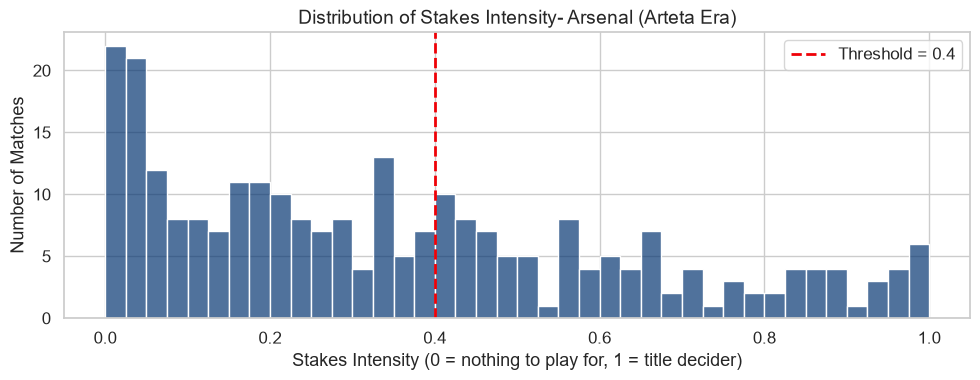

In [26]:
#Stakes intensity distribution

fig, ax = plt.subplots(figsize = (10, 4))

sns.histplot(data=ars, x = 'stakes_intensity',bins = 40, color= ARSENAL_NAVY, alpha = 0.7, ax = ax)

ax.axvline(x=0.4, color = ARSENAL_RED, linestyle='--', linewidth = 2, label = 'Threshold = 0.4')

ax.set_title('Distribution of Stakes Intensity- Arsenal (Arteta Era)',fontsize = 14)
ax.set_xlabel('Stakes Intensity (0 = nothing to play for, 1 = title decider)')
ax.set_ylabel('Number of Matches')
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
#High stakes count per season- check the split makes sense

stakes_by_season = (
    ars.groupby('season')['is_high_stakes']
    .agg(['sum','count'])
    .rename(columns={'sum': 'high_stakes','count':'total'})
)
stakes_by_season['normal'] = stakes_by_season['total'] - stakes_by_season['high_stakes']
stakes_by_season['pct_high'] = (stakes_by_season['high_stakes'] / stakes_by_season['total'] * 100).round(1)

print('High-stakes matches per season: ')
print(stakes_by_season)

High-stakes matches per season: 
        high_stakes  total  normal  pct_high
season                                      
1920              9     38      29      23.7
2021              8     38      30      21.1
2122             16     38      22      42.1
2223             18     38      20      47.4
2324             17     38      21      44.7
2425             17     38      21      44.7
2526             19     38      19      50.0


## SECTION A - Pre-Arteta Baseline (2017-19)

## Chart A1 - "The Starting Point"

Pre-Arteta Averages:  {'xG': np.float64(1.803), 'xGA': np.float64(1.395), 'xGD': np.float64(0.408)}
Arteta era Averages:  {'xG': np.float64(1.799), 'xGA': np.float64(1.124), 'xGD': np.float64(0.675)}


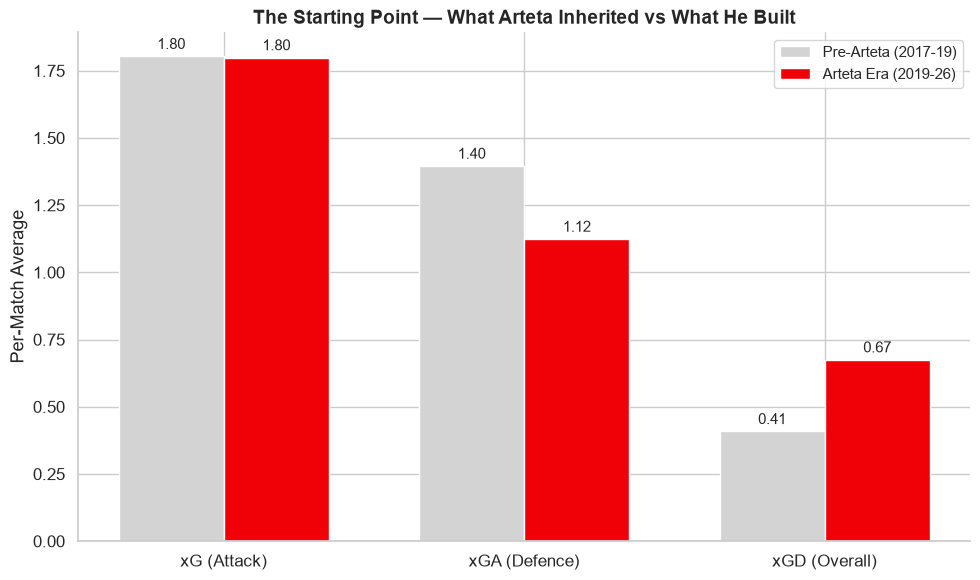

In [46]:
#Compute era averages
pre_avg = {
    'xG' : pre['xG'].mean(),
    'xGA': pre['xGA'].mean(),
    'xGD' : (pre['xG'] - pre['xGA']).mean()
}
arteta_avg = {
    'xG' : ars['xG'].mean(),
    'xGA' : ars['xGA'].mean(),
    'xGD' : ars['xgd'].mean()
}

print('Pre-Arteta Averages: ', {k: round(v,3) for k, v in pre_avg.items()})
print('Arteta era Averages: ', {k: round(v,3) for k,v in arteta_avg.items()})

#Chart A1
labels = ['xG (Attack)', 'xGA (Defence)', 'xGD (Overall)']
pre_vals = [pre_avg['xG'], pre_avg['xGA'], pre_avg['xGD']]
arteta_vals = [arteta_avg['xG'], arteta_avg['xGA'], arteta_avg['xGD']]

x = np.arange(len(labels))
width = 0.35

fix, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width/2, pre_vals, width, label = 'Pre-Arteta (2017-19)',
              color = LIGHT_GREY, edgecolor = 'white')
bars2 = ax.bar(x + width/2, arteta_vals, width, label = 'Arteta Era (2019-26)',
              color = ARSENAL_RED, edgecolor = 'white')

ax.bar_label(bars1, fmt = '%.2f', padding = 3, fontsize = 11)
ax.bar_label(bars2, fmt = '%.2f', padding = 3, fontsize = 11)

ax.axhline(y=0,color='grey',linewidth = 0.8,linestyle = '-')
ax.set_ylabel('Per-Match Average')
ax.set_title('The Starting Point — What Arteta Inherited vs What He Built',
             fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Section B - The Rise (2019-22)

## Chart B1 - Season-by-Season xG and xGA Trends

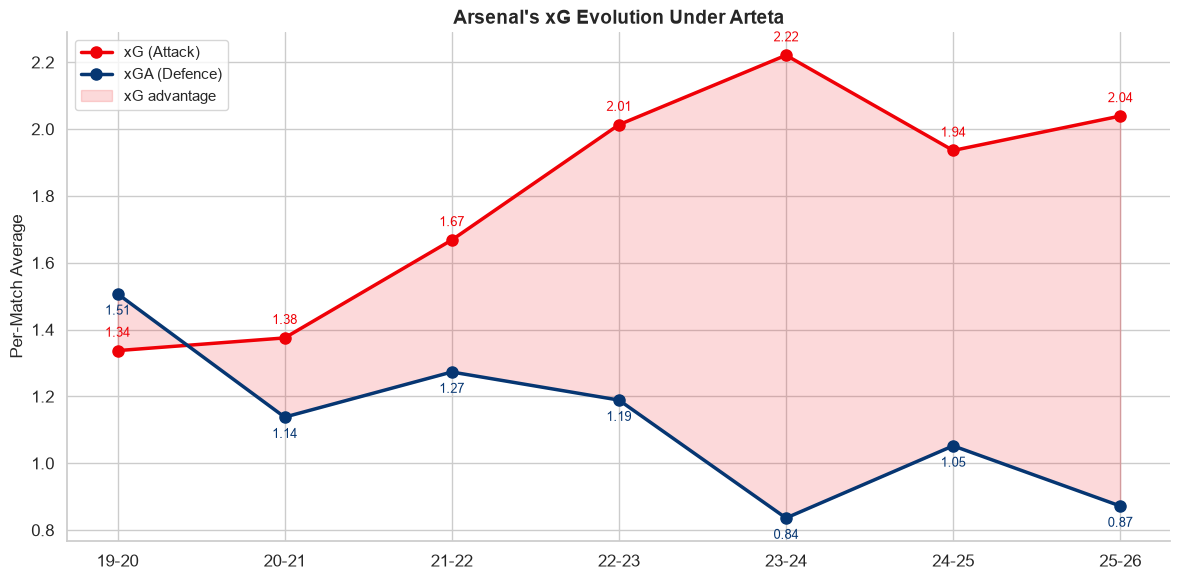


Season averages:
           xG    xGA
season              
1920    1.337  1.507
2021    1.375  1.138
2122    1.668  1.273
2223    2.013  1.189
2324    2.221  0.836
2425    1.936  1.052
2526    2.039  0.872


In [81]:
# Season Averages
season_avg = (
    ars.groupby('season')[['xG','xGA']]
    .mean().round(3)
)

# Season Labels for x- axis
SEASON_LABELS = {
    1920: '19-20', 2021: '20-21', 2122: '21-22',
    2223: '22-23', 2324: '23-24', 2425: '24-25', 2526: '25-26'
}
season_avg['label'] = season_avg.index.map(SEASON_LABELS)

# Chart B1
fig, ax = plt.subplots(figsize = (12,6))

x_pos = range(len(season_avg))

ax.plot(x_pos, season_avg['xG'], marker = 'o', linewidth = 2.5, markersize=8,
       color = ARSENAL_RED, label = 'xG (Attack)', zorder = 3)
ax.plot(x_pos, season_avg['xGA'], marker = 'o', linewidth = 2.5, markersize=8,
       color = ARSENAL_NAVY, label = 'xGA (Defence)', zorder = 3)

#Shade the gap bw xG and xGA
ax.fill_between(x_pos, season_avg['xG'],season_avg['xGA'],
               alpha = 0.15, color = ARSENAL_RED, label = 'xG advantage')

#Annotate values on eachpoint
for i,(xg,xga) in enumerate(zip(season_avg['xG'], season_avg['xGA'])):
    ax.annotate(f'{xg:.2f}', (i,xg), textcoords='offset points', xytext= (0,10),
               ha='center',fontsize = 9, color = ARSENAL_RED)
    ax.annotate(f'{xga:.2f}', (i,xga), textcoords = 'offset points', 
                xytext = (0,-15), ha = 'center', fontsize = 9, color = ARSENAL_NAVY)

ax.set_xticks(x_pos)
ax.set_xticklabels(season_avg['label'], fontsize = 12)
ax.set_ylabel('Per-Match Average', fontsize = 12)
ax.set_title("Arsenal's xG Evolution Under Arteta", fontsize = 14, fontweight='bold')
ax.legend(loc='upper left',fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nSeason averages:')
print(season_avg[['xG', 'xGA']].to_string())

## Chart B2 - Points per Game & Win Rate by Season

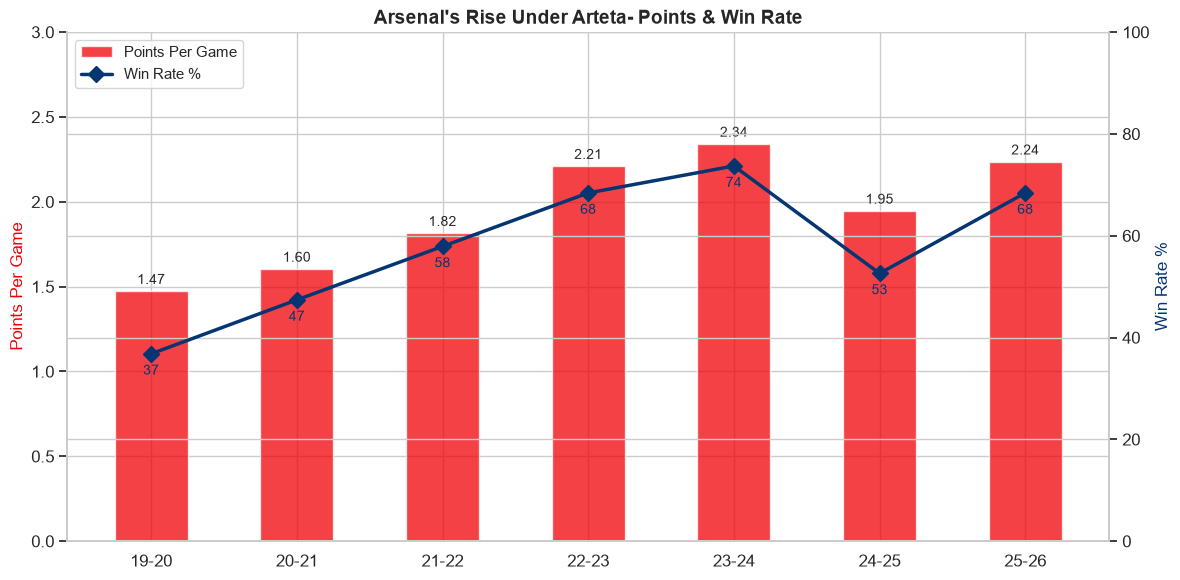


Season performance:
          ppg  win_rate_pct  total_pts
season                                
1920    1.474          36.8         56
2021    1.605          47.4         61
2122    1.816          57.9         69
2223    2.211          68.4         84
2324    2.342          73.7         89
2425    1.947          52.6         74
2526    2.237          68.4         85


In [102]:
#Compute PPG and win rate per season
season_perf = ars.groupby('season').agg(
    ppg = ('points', 'mean'),
    win_rate = ('is_win', 'mean'),
    total_pts = ('points', 'sum')
).round(3)
season_perf['win_rate_pct'] = (season_perf['win_rate']*100).round(2)
season_perf['label'] = season_perf.index.map(SEASON_LABELS)

#Chart B2
fix, ax1 = plt.subplots(figsize=(12,6))

x_pos = range(len(season_perf))

# Bars = PPG on left axis
bars = ax1.bar(x_pos, season_perf['ppg'], color = ARSENAL_RED, alpha = 0.75,
              width = 0.5, label = 'Points Per Game',zorder = 2)
ax1.bar_label(bars,fmt = '%.2f', padding = 3, fontsize = 10)
ax1.set_ylabel('Points Per Game', fontsize = 12, color = ARSENAL_RED)
ax1.set_ylim(0,3)

# Line = Win rate on right axis
ax2 = ax1.twinx()
ax2.plot(x_pos, season_perf['win_rate_pct'], marker = 'D', linewidth = 2.5,
        markersize = 8, color = ARSENAL_NAVY, label = "Win Rate %", zorder = 3)
ax2.set_ylabel('Win Rate %', fontsize = 12, color = ARSENAL_NAVY)
ax2.set_ylim(0,100)

#Annotate win rate values
for i, wr in enumerate(season_perf['win_rate_pct']) :
    ax2.annotate(f'{wr:.0f}', (i,wr), textcoords='offset points',
                xytext=(0,-15), ha='center',fontsize=10,color = ARSENAL_NAVY)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(season_perf['label'],fontsize=12)
ax1.set_title("Arsenal's Rise Under Arteta- Points & Win Rate",
             fontsize = 14, fontweight = 'bold')

#Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc = 'upper left', fontsize = 11)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nSeason performance:')
print(season_perf[['ppg', 'win_rate_pct', 'total_pts']].to_string())

## Section C - The Three Bottles (2022-25)

## Chart C1 - Drop Index Scatter: All Arteta-Era Matches

In [103]:
# Compute per match Drop index
season_xg_avg = ars.groupby('season')['xG'].transform('mean')
season_xga_avg = ars.groupby('season')['xGA'].transform('mean')

#Positive = underperformed, Negative = overperformed
ars ['match_drop_index'] = (
    (season_xg_avg - ars['xG']) + (season_xga_avg - ars['xGA'])
)/2

print(f'Match Drop Index — mean: {ars["match_drop_index"].mean():.4f}  '
      f'(should be ~0, it\'s a deviation from average)')
print(f'Range: {ars["match_drop_index"].min():.3f} to {ars["match_drop_index"].max():.3f}')

Match Drop Index — mean: -0.0000  (should be ~0, it's a deviation from average)
Range: -2.222 to 1.230


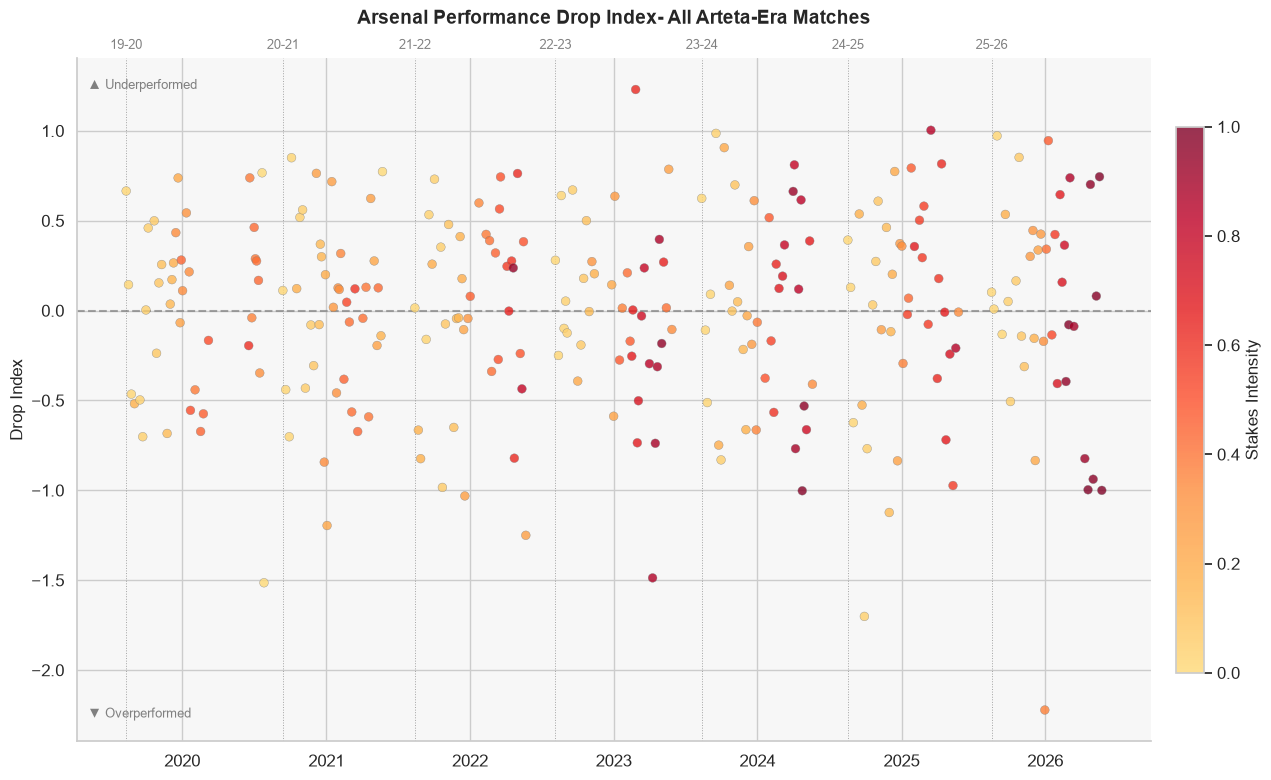

In [154]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# 1. Fetch the base colormap using the modern registry
base_cmap = mpl.colormaps['YlOrRd']

# 2. Slice the colormap array (skipping the first 25%)
truncated_colors = base_cmap(np.linspace(0.25, 1.0, 256))

# 3. Create the new truncated colormap
truncated_cmap = LinearSegmentedColormap.from_list(
    'YlOrRd_dark',
    truncated_colors
)

# Chart C1: Drop Index scatter over time
fig, ax = plt.subplots(figsize=(14,8))

ax.set_facecolor('#f7f7f7')
# Scatter with continuous colours = stakes_intensity
scatter = ax.scatter(
    ars['date'],ars['match_drop_index'],
    c=ars['stakes_intensity'],    # colour mapped to stakes
    cmap = truncated_cmap,
    s=40, alpha = 0.8, edgecolors = 'grey', linewidths=0.3, zorder = 3
)

# Ref line y=0
ax.axhline(y=0, color = 'grey', linewidth = 1.5, linestyle = '--', alpha = 0.7)

# Season boundary lines
season_starts = ars.groupby('season')['date'].min()
for season_code, start_date in season_starts.items() :
    ax.axvline(x = start_date, color = 'grey', linewidth = 0.7,
              linestyle = ':', alpha = 0.7)
    label = SEASON_LABELS.get(season_code,str(season_code))
    ax.annotate(label, xy=(start_date, 1), xycoords=('data', 'axes fraction'),
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, color='grey', ha='center', va='bottom')

# Colourbar- gradient explanation
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8,pad=0.02)
cbar.set_label('Stakes Intensity',fontsize=12)

ax.set_title('Arsenal Performance Drop Index- All Arteta-Era Matches',
            fontsize=14, fontweight='bold',pad = 25)
ax.set_xlabel('')
ax.set_ylabel('Drop Index', fontsize=12)
ax.text(0.01, 0.97, '▲ Underperformed', transform=ax.transAxes,
        fontsize=9, color='grey', ha='left', va='top')
ax.text(0.01, 0.03, '▼ Overperformed', transform=ax.transAxes,
        fontsize=9, color='grey', ha='left', va='bottom')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Chart C2 - Heatmap: Gameweek x Season Drop Index